# Assignment 3

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Clustering and Resampling

Let's set up our workspace and use the **Wine dataset** from `scikit-learn`. This dataset is a classic dataset used for clustering tasks. It consists of many samples of wine. Here are the key features and characteristics of the dataset:

##### Features (13 chemical properties):
1. Alcohol: The percentage of alcohol in the wine.
2. Malic acid: A type of acid found in grapes, contributing to wine’s tartness.
3. Ash: The total amount of non-volatile substances left after burning the wine
4. Alcalinity of ash: Measures the alkalinity of the ash component of wine.
5. Magnesium: The amount of magnesium in the wine (measured in mg/L).
6. Total phenols: Represents the total amount of phenolic compounds in wine.
7. Flavanoids: A type of phenolic compound responsible for bitterness and astringency.
8. Nonflavanoid phenols: Phenolic compounds that are not flavonoids.
9. Proanthocyanins: A type of tannin that affects astringency and bitterness.
10. Color intensity: Measures the depth or intensity of the wine’s color. 
11. Hue: The shade of color in the wine (ratio of red to yellow tones).
12. OD280/OD315 of diluted wines: Measures the wine’s absorbance at 280 nm and 315 nm, indicating phenol concentration.
13. Proline: An amino acid found in wine, often associated with aging potential and quality.

In [40]:
# Import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


#### **Question 1:** 
#### Data inspection

#### Load the Wine dataset:

Use scikit-learn to load the Wine dataset and convert it into a Pandas DataFrame.
Display the first few rows of the dataset. How many observations (rows) and features (columns) does the dataset contain?

In [41]:
from sklearn.datasets import load_wine
# Load the Wine dataset
wine_data = load_wine()

# Convert to DataFrame
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)

# Display the DataFrame
print(wine_df)

# Your code here...
# See below for code exploring the data. There are 178 rows and 13 columns of data



     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonflavanoid_phenols  proanthocyan

In [42]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [43]:
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


#### **Question 2:** 
#### Data-visualization

Let's create plots to visualize the relationships between the features (e.g., alcohol, malic acid, ash...).


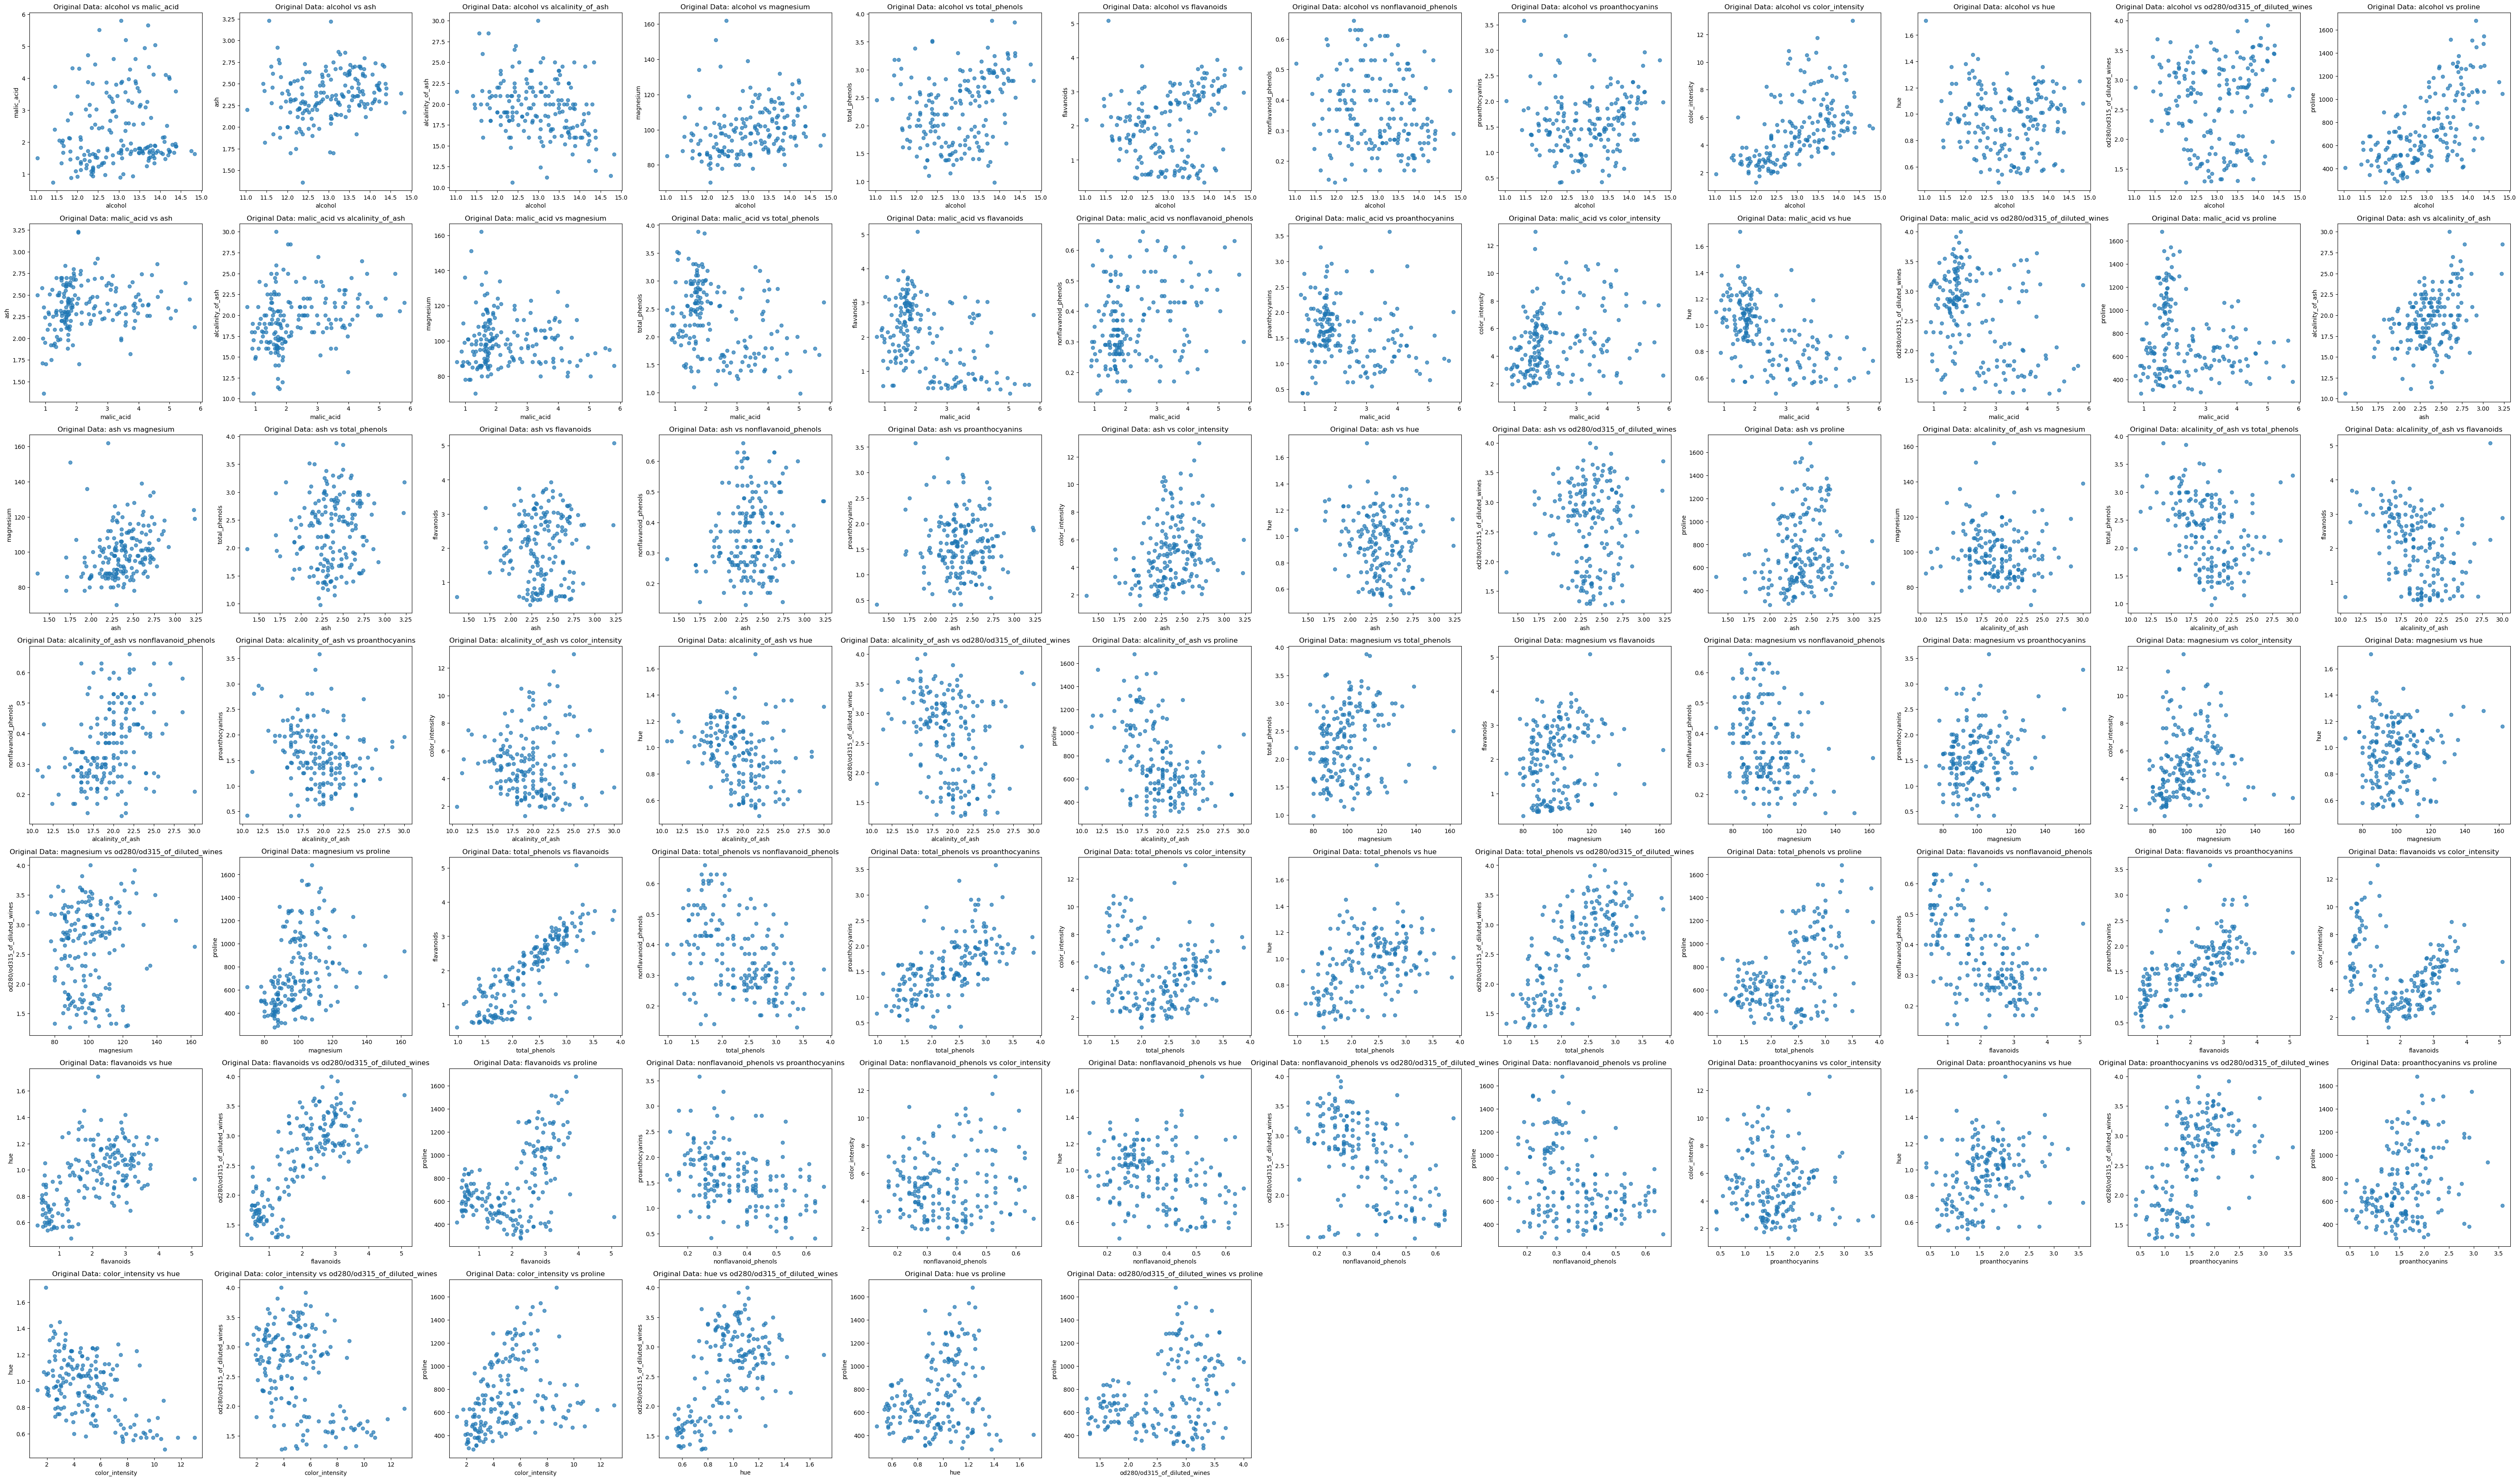

In [53]:
def plot_feature_pairs(data, feature_names, color_labels=None, title_prefix=''):
    """
    Helper function to create scatter plots for all possible pairs of features.
    
    Parameters:
    - data: DataFrame containing the features to be plotted.
    - feature_names: List of feature names to be used in plotting.
    - color_labels: Optional. Cluster or class labels to color the scatter plots.
    - title_prefix: Optional. Prefix for plot titles to distinguish between different sets of plots.
    """
    # Create a figure for the scatter plots
    plt.figure(figsize=(60, 60))
    
    # Counter for subplot index
    plot_number = 1
    
    # Loop through each pair of features
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            plt.subplot(len(feature_names)-1, len(feature_names)-1, plot_number)
            
            # Scatter plot colored by labels if provided
            if color_labels is not None:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], 
                            c=color_labels, cmap='viridis', alpha=0.7)
            else:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], alpha=0.7)
            
            plt.xlabel(feature_names[i])
            plt.ylabel(feature_names[j])
            plt.title(f'{title_prefix}{feature_names[i]} vs {feature_names[j]}')
            
            # Increment the plot number
            plot_number += 1

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

# Get feature names
feature_names = wine_df.columns

# Use the helper function to plot scatter plots without coloring by cluster labels
plot_feature_pairs(wine_df, feature_names, title_prefix='Original Data: ')

**Question:**
- Do you notice any patterns or relationships between the different features? How might these patterns help in distinguishing between different species?

In [96]:
#> Your answer...

#Some potential relationships based on correlations:

#alcohol: as alcohol increases, magnesium, colour intensity and proline increase;
#malic acid: as malic acid increases, magnesium, flavenoids and hue tend to decrease;
#ash: as ash increases, magnesium increases;
#phenols: as phenols increase, flavenoids increase (high correlation)

#Some potential relationships based on clustering:

# malic acid & hue: the data suggest two clusters of wines, one with low malic acid and medium hue, and a second with high malic acid and lower hue
# flavinoids & proline: the data suggest two clusters of wines, one with low flavinoids and low proline, and a second with high flavinoids and high proline
# total phenols & proline: the data suggest two clusters of wines, one with low phenols and low proline, and a second with high phenols and high proline - 
# this is not surprising given the linear relationship between phenols and flavenoids

#The above are just a few of the relationships. Where there are strong relationships (i.e. high R-squared or clustering), we can investigate whether the wines can be grouped in terms of these characteristics.

#### **Question 3:** 
#### Data cleaning

In [13]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Scale all the features in the dataset
scaled_features = scaler.fit_transform(wine_df)

# Create a new DataFrame with scaled features
scaled_wine_df = pd.DataFrame(scaled_features, columns=wine_data.feature_names)

# Display the first few rows of the scaled DataFrame
print(scaled_wine_df.head())

    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  1.518613   -0.562250  0.232053          -1.169593   1.913905   
1  0.246290   -0.499413 -0.827996          -2.490847   0.018145   
2  0.196879    0.021231  1.109334          -0.268738   0.088358   
3  1.691550   -0.346811  0.487926          -0.809251   0.930918   
4  0.295700    0.227694  1.840403           0.451946   1.281985   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.808997    1.034819             -0.659563         1.224884   
1       0.568648    0.733629             -0.820719        -0.544721   
2       0.808997    1.215533             -0.498407         2.135968   
3       2.491446    1.466525             -0.981875         1.032155   
4       0.808997    0.663351              0.226796         0.401404   

   color_intensity       hue  od280/od315_of_diluted_wines   proline  
0         0.251717  0.362177                      1.847920  1.013009  
1        -0.293321  0.406051

In [15]:
# easier to view with this code
scaled_wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874


Why is it important to standardize the features of a dataset before applying clustering algorithms like K-Means? Discuss the implications of using unstandardized data in your analysis.

> Your answer here ...

We standardize the variables in a dataset to ensure a fair contribution from all variables, which allows the model to consider each variable equally based on its relationship to the outcome variable or, in the case of clustering, its contribution to the distance calculations. This prevents any single feature from dominating the results due to its scale. If we did not standardize, we would be evaluating the scale of each variable rather than its actual contribution.

#### **Question 4:** 
#### K-means clustering 

Apply the K-Means clustering algorithm to the Wine dataset. Choose the value 3 for the number of clusters (`k=3`) and fit the model. Assign cluster labels to the original data and add them as a new column in the DataFrame.

In [32]:
# Your answer...

# Perform K-means clustering
kmeans = KMeans(n_clusters=3, random_state=0)
clusters = kmeans.fit(scaled_wine_df)


In [33]:
# Create a copy of the DataFrame for clustering and modification
clustered_wine_data = scaled_wine_df.copy()

In [34]:
# Add cluster labels to the copied DataFrame
clustered_wine_data['Cluster'] = clusters.labels_

# Display the updated DataFrame with the 'Cluster' column
clustered_wine_data

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,Cluster
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009,2
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242,2
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148,2
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574,2
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.876275,2.974543,0.305159,0.301803,-0.332922,-0.985614,-1.424900,1.274310,-0.930179,1.142811,-1.392758,-1.231206,-0.021952,1
174,0.493343,1.412609,0.414820,1.052516,0.158572,-0.793334,-1.284344,0.549108,-0.316950,0.969783,-1.129518,-1.485445,0.009893,1
175,0.332758,1.744744,-0.389355,0.151661,1.422412,-1.129824,-1.344582,0.549108,-0.422075,2.224236,-1.612125,-1.485445,0.280575,1
176,0.209232,0.227694,0.012732,0.151661,1.422412,-1.033684,-1.354622,1.354888,-0.229346,1.834923,-1.568252,-1.400699,0.296498,1


In [ ]:
# using this code, we can see how the data are distributed across the clusters; as it turns out, they are distributed quite evenly
from collections import Counter
Counter(clustered_wine_data ['Cluster'])

Counter({0: 65, 2: 62, 1: 51})

In [ ]:
# The code provided below for this questions does not (on its own) result in plots of the clustered data, and runs continually on my machine without stopping, so I replaced it with a longer revised version of the code from Question 2 above.

#plot_feature_pairs(clustered_wine_data, feature_names, color_labels=clustered_wine_data['Cluster'], title_prefix='Clustered Data: ')

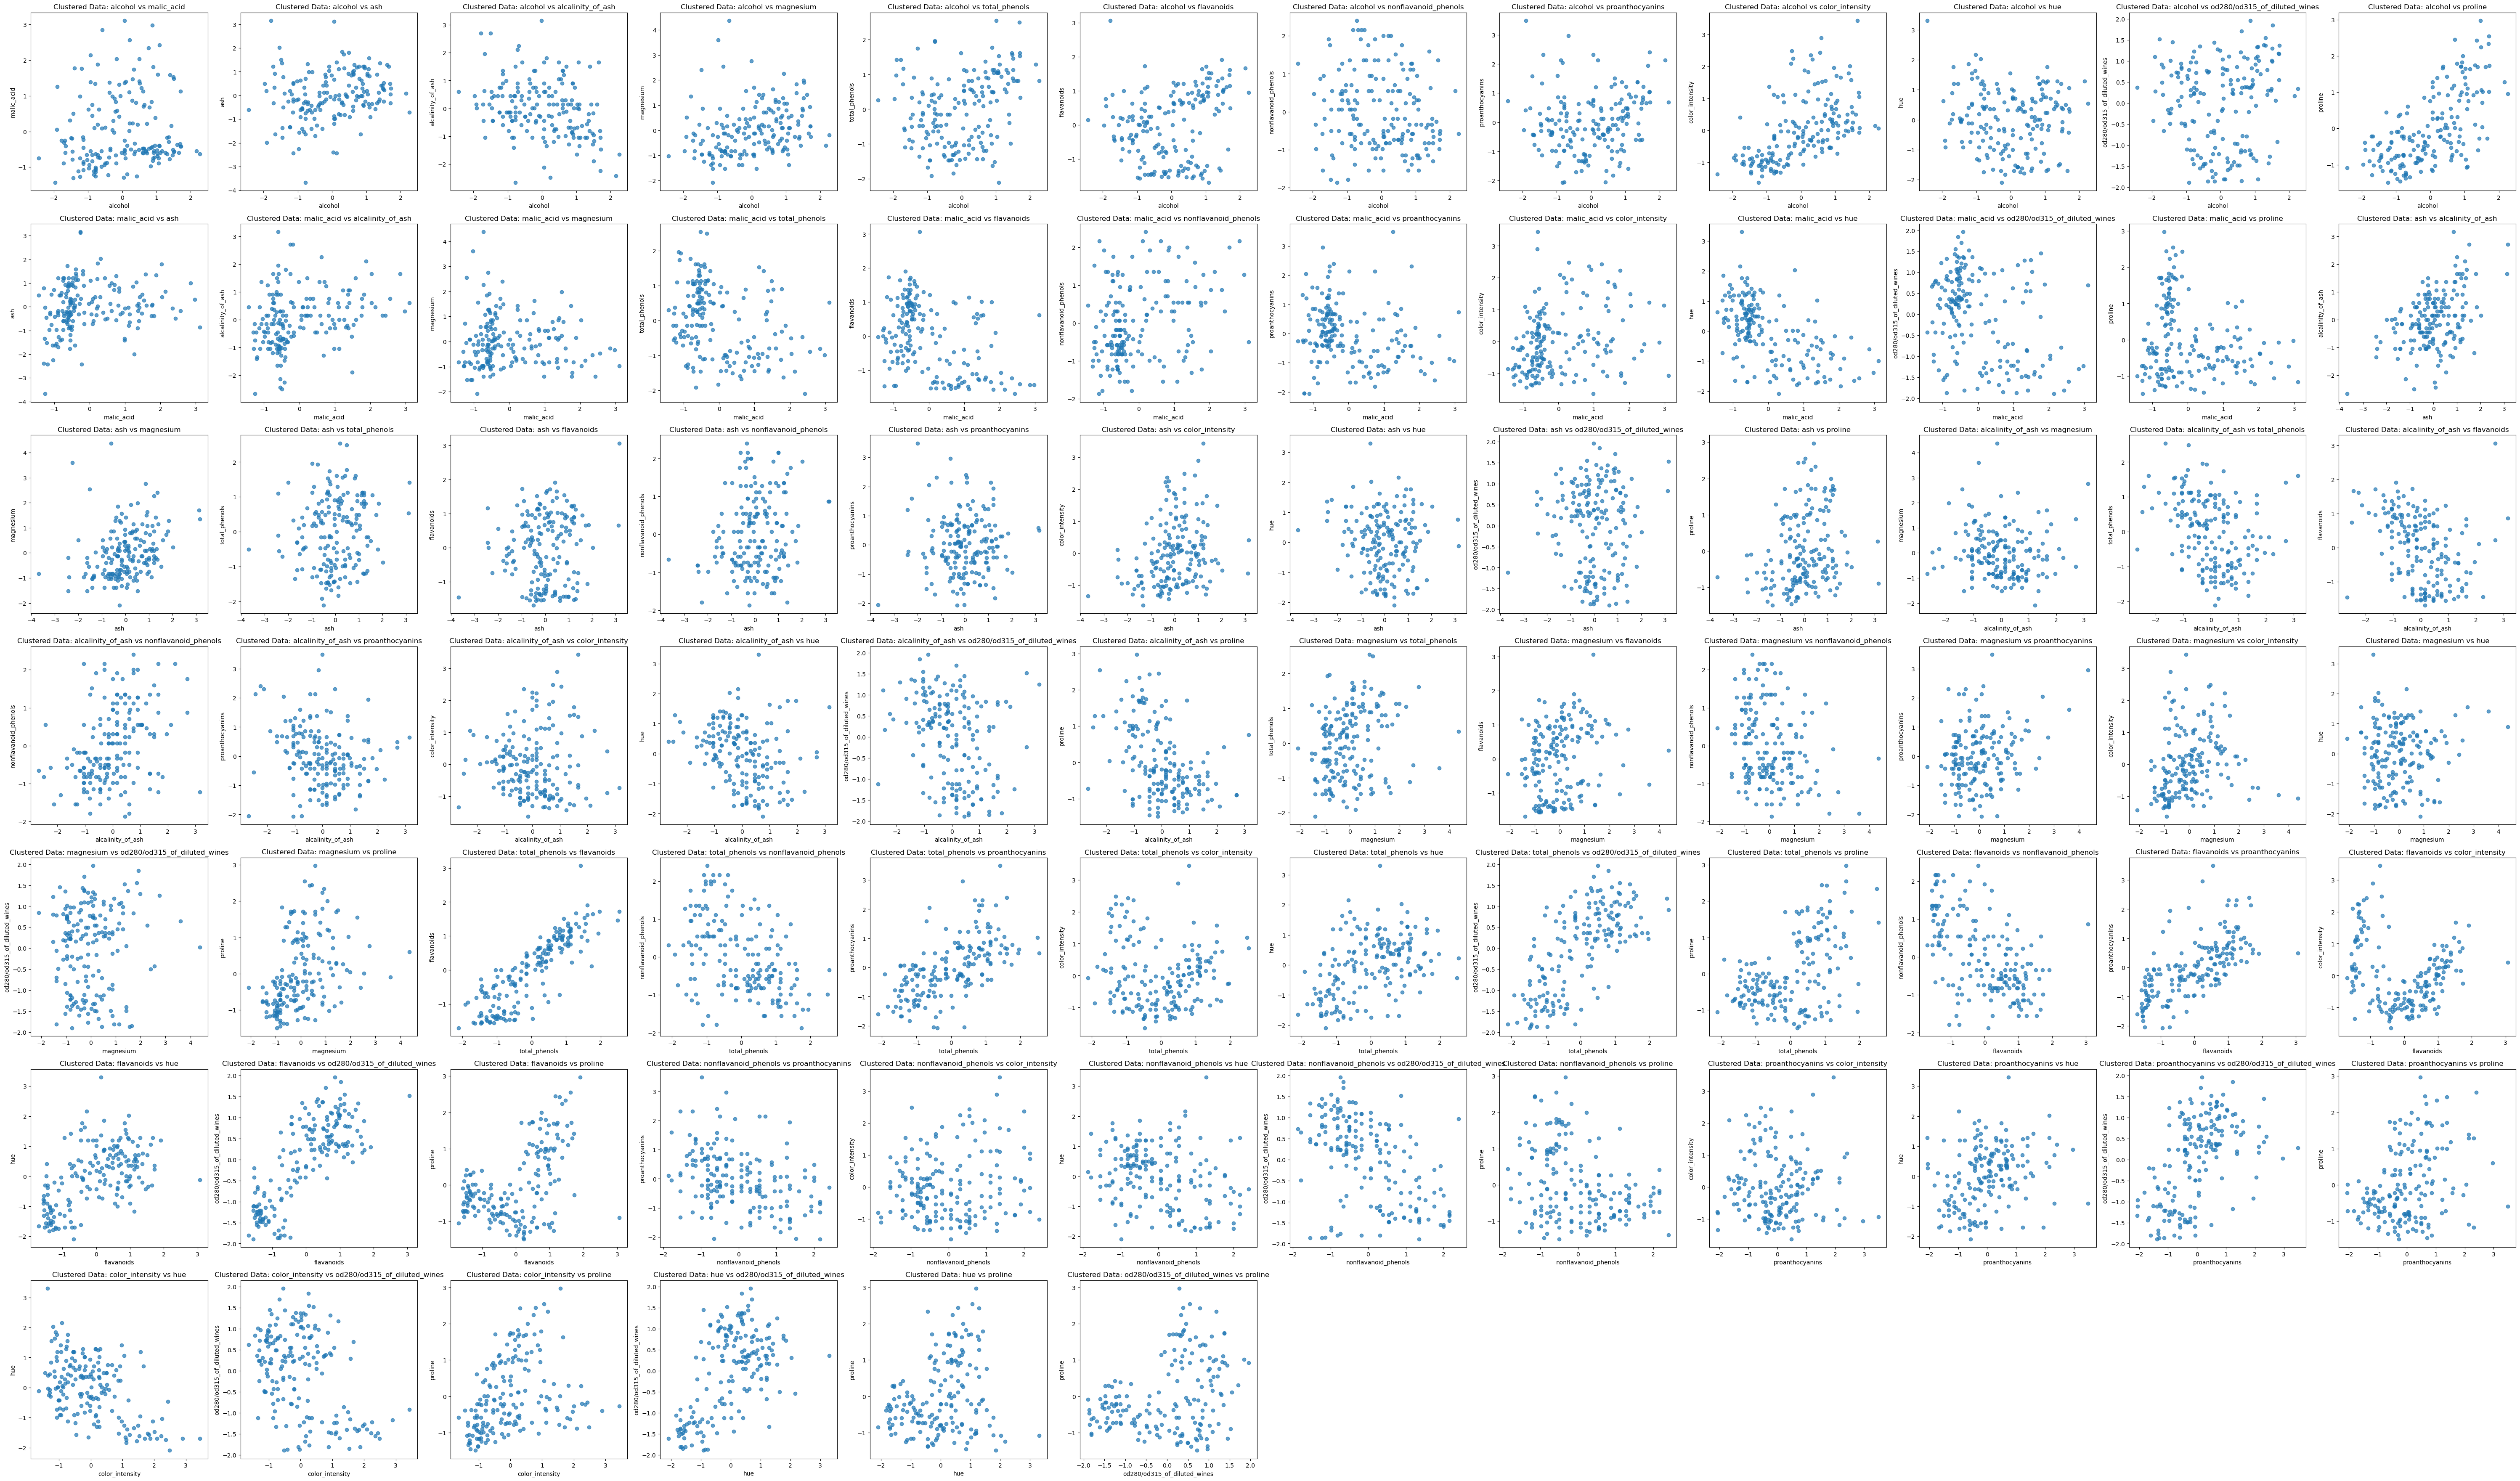

In [38]:
def plot_feature_pairs(data, feature_names, color_labels=None, title_prefix=''):
 
    # Create a figure for the scatter plots
    plt.figure(figsize=(60, 60))
    
    # Counter for subplot index
    plot_number = 1
    
    # Loop through each pair of features
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            plt.subplot(len(feature_names)-1, len(feature_names)-1, plot_number)
            
            # Scatter plot colored by labels if provided
            if color_labels is not None:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], 
                            c=color_labels, cmap='viridis', alpha=0.7)
            else:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], alpha=0.7)
            
            plt.xlabel(feature_names[i])
            plt.ylabel(feature_names[j])
            plt.title(f'{title_prefix}{feature_names[i]} vs {feature_names[j]}')
            
            # Increment the plot number
            plot_number += 1

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

# Get feature names, and remove the 'cluster' column from the feature names
#clustered_wine_data = clustered_wine_data.iloc[:, :-1]
clustered_wine_data = clustered_wine_data.iloc[:, :-1]
feature_names = clustered_wine_data.columns

# Use the helper function to plot scatter plots without coloring by cluster labels
plot_feature_pairs(clustered_wine_data, feature_names, title_prefix='Clustered Data: ')

We chose `k=3` for the number of clusters arbitrarily. However, in a real-world scenario, it is important to determine the optimal number of clusters using appropriate methods.

**Question**: What is one method commonly used to determine the optimal number of clusters in K-means clustering, and why is this method helpful?

> Your answer here...

In k means clustering, selecting the appropriate k is important since too small of a k results in merging of clusters (and a high within-cluster sum of squared distance (WSSD)), while too large of a k leads to excessive merging that creates differences that are not real. By running k means clustering across several k, we can see the relationship between k and WSSD. Mathematically, as k increases the number of clusters decreases. By graphing this relationship between k and WSSE, we can use the "elbow method" to determine at which value of k, the value of WSSD decreases only marginally. That is the optimal value of k. 

#### **Question 5:** 
#### Bootstrapping 

Implement bootstrapping on the mean of `color intensity`. Generate 10000 bootstrap samples, calculate the mean for each sample, and compute a 90% confidence interval.

In [ ]:
# Your answer here...

# The dataset wind_df is presumed to be a sample (so we do not need to resample from wind_df)
# To start, I determined the mean of the entire sample

mean_color_intensity = wine_df["color_intensity"].mean()
mean_color_intensity

5.058089882022472

In [83]:
wine_df["color_intensity"].min()

1.28

In [84]:
wine_df["color_intensity"].max()

13.0

In [77]:
np.random.seed(123)

In [ ]:
# To being the sampling, initialize an empty list to store the samples
sample_list = []

# Take 10,000 samples, use frac=1 to sample from all rows, and sample with replacement
for i in range(10_000):
    sample = wine_df.sample(frac=1, replace=True) # Randomly sample from all rows with replacement
    sample = sample.assign(replicate=i)  # Add a column to track the replicate number
    sample_list.append(sample)           # Append the sample to the sample list

# Combine all samples into one large DataFrame
all_boot_samples = pd.concat(sample_list)

In [68]:
all_boot_samples.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1780000 entries, 78 to 127
Data columns (total 14 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   alcohol                       float64
 1   malic_acid                    float64
 2   ash                           float64
 3   alcalinity_of_ash             float64
 4   magnesium                     float64
 5   total_phenols                 float64
 6   flavanoids                    float64
 7   nonflavanoid_phenols          float64
 8   proanthocyanins               float64
 9   color_intensity               float64
 10  hue                           float64
 11  od280/od315_of_diluted_wines  float64
 12  proline                       float64
 13  replicate                     int64  
dtypes: float64(13), int64(1)
memory usage: 203.7 MB


In [ ]:
# Calculate the mean color intensity for each bootstrap sample (replicate)
boot_means = all_boot_samples.groupby('replicate')['color_intensity'].mean().reset_index(name='color_intensity_sample_mean')
boot_means

,replicate,color_intensity_sample_mean
0,0,4.930169
1,1,4.892921
2,2,5.042303
3,3,4.851404
4,4,4.898090
...,...,...
9995,9995,5.013034
9996,9996,5.222865
9997,9997,5.038876
9998,9998,5.042022


In [75]:
lower_bound = boot_means['color_intensity_sample_mean'].quantile(0.05)
upper_bound = boot_means['color_intensity_sample_mean'].quantile(0.95)
ci_bounds = [lower_bound, upper_bound]
ci_bounds

[4.779370785955057, 5.347415708146068]

In [ ]:
# We can check to see if our mean is bounded by our confidence interval, and how it compares to the initial mean of wine_df
boot_means['color_intensity_sample_mean'].mean()

5.059318252724719

In [78]:
boot_means['color_intensity_sample_mean'].min()

4.473820219101124

**Question:**
- Why do we use bootstrapping in this context? What does it help us understand about the mean?

>  Your answer...

A single sample estimate may not accurately reflect the population, and reporting only statistics (e.g. mean, median, standard deviation) from that sample may be insufficient. Bootstrapping allows us to construct confidence intervals on the statistic, providing a range of possible values for the population parameter from our single sample. 

**Question:**
- What is the purpose of calculating the confidence interval from the bootstrap samples? How does it help us interpret the variability of the estimate?

> Your answer...

The confidence interval provides some information about how much (or how little) the population of wines varies on the particular chemical property of colour intensity. Here the 5% confidence interval is 4.779 and the 95% confidence interval is 5.347 on a bootstrap mean of 5.059, and an initial sample mean of 5.058. This provides a range of plausible values for a sample mean.

**Question:**

- Reflect on the variability observed in the bootstrapped means and discuss whether the mean of the color intensity appears to be a stable and reliable estimate based on the confidence interval and the spread of the bootstrapped means.

> Your answer here...

It is easier to answer this question by first plotting the bootstrapped means and determining the min, max and standard deviation (see below). The extent to which the mean of the colour intensity is a "stable and reliable estimate based on the confidence interval and the spread of the bootstrapped means" depends on both the numerical variability but also on the context. Looking at the plot and statistics below, we can see that the distribution is quite narrow with a standard deviation of 0.17 on a mean of 5.059, suggesting a stable mean for colour intensity. However, we also need to know something about colour intensity and the extent to which is predicts the type of wine or other chemical properties of the wine. Perhaps, only a small variation in colour intensity signals the difference between a Merlot and a Rioja? 

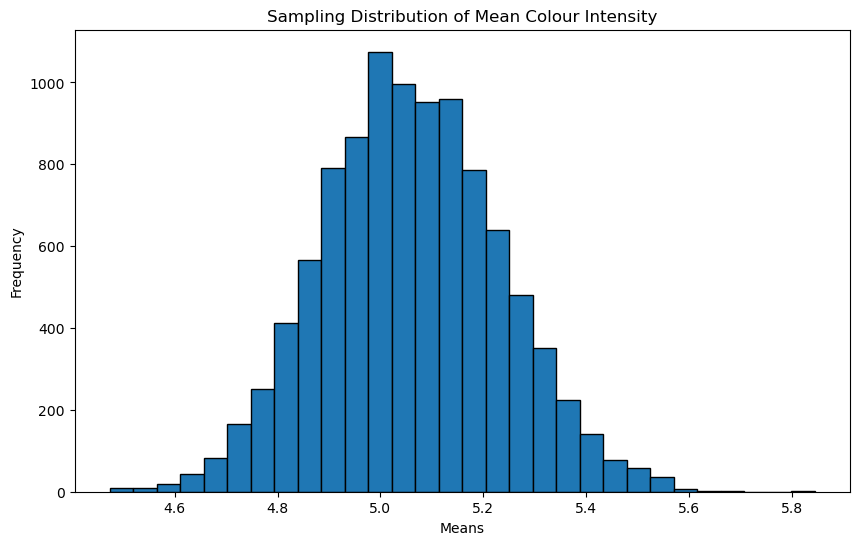

In [85]:
# Plot the histogram of the sampling distribution
plt.figure(figsize=(10, 6))
plt.hist(boot_means['color_intensity_sample_mean'], bins=30, edgecolor='black')


# Add titles and labels
plt.title('Sampling Distribution of Mean Colour Intensity')
plt.xlabel('Means')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [86]:
boot_means['color_intensity_sample_mean'].min()

4.473820219101124

In [87]:
boot_means['color_intensity_sample_mean'].max()

5.844775280898876

In [90]:
import statistics

In [94]:
print(statistics.pstdev(boot_means['color_intensity_sample_mean']))

0.17346293064681012


# Criteria


| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is thoroughly inspected for the number of variables, observations, and data types, and relevant insights are noted. | Data inspection is missing or lacks detail.         |
| **Data Visualization**                                 | Visualizations (e.g., scatter plots) are correctly interpreted to explore relationships between features and species. | Visualizations are not correctly interpreted. |
| **Clustering Implementation**                           | K-Means clustering is correctly implemented, and cluster labels are appropriately assigned to the dataset.            | K-Means clustering is missing or incorrectly implemented. |
| **Bootstrapping Process**                              | Bootstrapping is correctly performed, and results are used to assess variable mean stability. | Bootstrapping is missing or incorrectly performed. |

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 03/28/2025`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_3.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#dc-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
